# Atividade I – Bank Marketing

Aluno: Gustavo Carvalho | RA: 311941

**Objetivo:** prever se o cliente vai aderir ao depósito a prazo (`aderiu = sim`, classe positiva) com k-NN, Naive Bayes e regressão logística, comparando dois cenários de atributos.

Roteiro: 1) análise exploratória · 2) preparação · 3) modelagem (hiperparâmetros por validação cruzada) · 4) avaliação no teste, que só é usado no final.

## 0. Bibliotecas e semente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 42  # random_state fixo em todas as operações aleatórias
pd.set_option("display.max_columns", None)

## 1. Análise exploratória
### 1.1 Dimensões e tipos

In [ ]:
df = pd.read_csv("bank_marketing_completo.csv")
print("Dimensões:", df.shape)
df.info()

Dimensões: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        41188 non-null  int64  
 1   profissao                    41188 non-null  str    
 2   estado_civil                 41188 non-null  str    
 3   escolaridade                 41188 non-null  str    
 4   inadimplente                 41188 non-null  str    
 5   financiamento_imobiliario    41188 non-null  str    
 6   emprestimo_pessoal           41188 non-null  str    
 7   meio_contato                 41188 non-null  str    
 8   mes                          41188 non-null  str    
 9   dia_semana                   41188 non-null  str    
 10  duracao_ligacao_seg          41188 non-null  int64  
 11  contatos_campanha_atual      41188 non-null  int64  
 12  dias_desde_ultimo_contato    41188 non-null  int64  
 13  cont

### 1.2 Qualidade da base

In [ ]:
categoricas = ["profissao", "estado_civil", "escolaridade", "inadimplente", "financiamento_imobiliario",
               "emprestimo_pessoal", "meio_contato", "mes", "dia_semana", "resultado_campanha_anterior"]

print("Valores ausentes (NaN):", df.isna().sum().sum())
print("Linhas duplicadas:     ", df.duplicated().sum())
print("% com dias_desde_ultimo_contato = 999 (nunca contatado):",
      round((df["dias_desde_ultimo_contato"] == 999).mean() * 100, 1))
desconhecido = (df[categoricas] == "desconhecido").sum()
print("\nContagem de 'desconhecido' por coluna:")
print(desconhecido[desconhecido > 0])
print("\n", df["inadimplente"].value_counts())

Valores ausentes (NaN): 0
Linhas duplicadas:      12
% com dias_desde_ultimo_contato = 999 (nunca contatado): 96.3

Contagem de 'desconhecido' por coluna:
profissao                     330
estado_civil                   80
escolaridade                 1731
inadimplente                 8597
financiamento_imobiliario     990
emprestimo_pessoal            990
dtype: int64

 inadimplente
nao             32588
desconhecido     8597
sim                 3
Name: count, dtype: int64


In [ ]:
df.describe().T[["min", "max", "mean"]].round(2)

,min,max,mean
idade,17.00,98.00,40.02
duracao_ligacao_seg,0.00,4918.00,258.29
contatos_campanha_atual,1.00,56.00,2.57
dias_desde_ultimo_contato,0.00,999.00,962.48
contatos_anteriores,0.00,7.00,0.17
taxa_variacao_emprego,-3.40,1.40,0.08
indice_precos_consumidor,92.20,94.77,93.58
indice_confianca_consumidor,-50.80,-26.90,-40.50
euribor_3m,0.63,5.04,3.62
numero_empregados,4963.60,5228.10,5167.04


### 1.3 Distribuição da variável-alvo (recodificada para 1 = sim, 0 = nao: regra fixa, classe positiva = 1)

In [ ]:
df["aderiu"] = (df["aderiu"] == "sim").astype(int)
print(df["aderiu"].value_counts())
print((df["aderiu"].value_counts(normalize=True) * 100).round(1))
print("\nLinha de base: prever sempre 0 (nao) daria acurácia de",
      round((df["aderiu"] == 0).mean() * 100, 1), "%")

aderiu
0    36548
1     4640
Name: count, dtype: int64
aderiu
0    88.7
1    11.3
Name: proportion, dtype: float64

Linha de base: prever sempre 0 (nao) daria acurácia de 88.7 %


### 1.4 Atributos × adesão

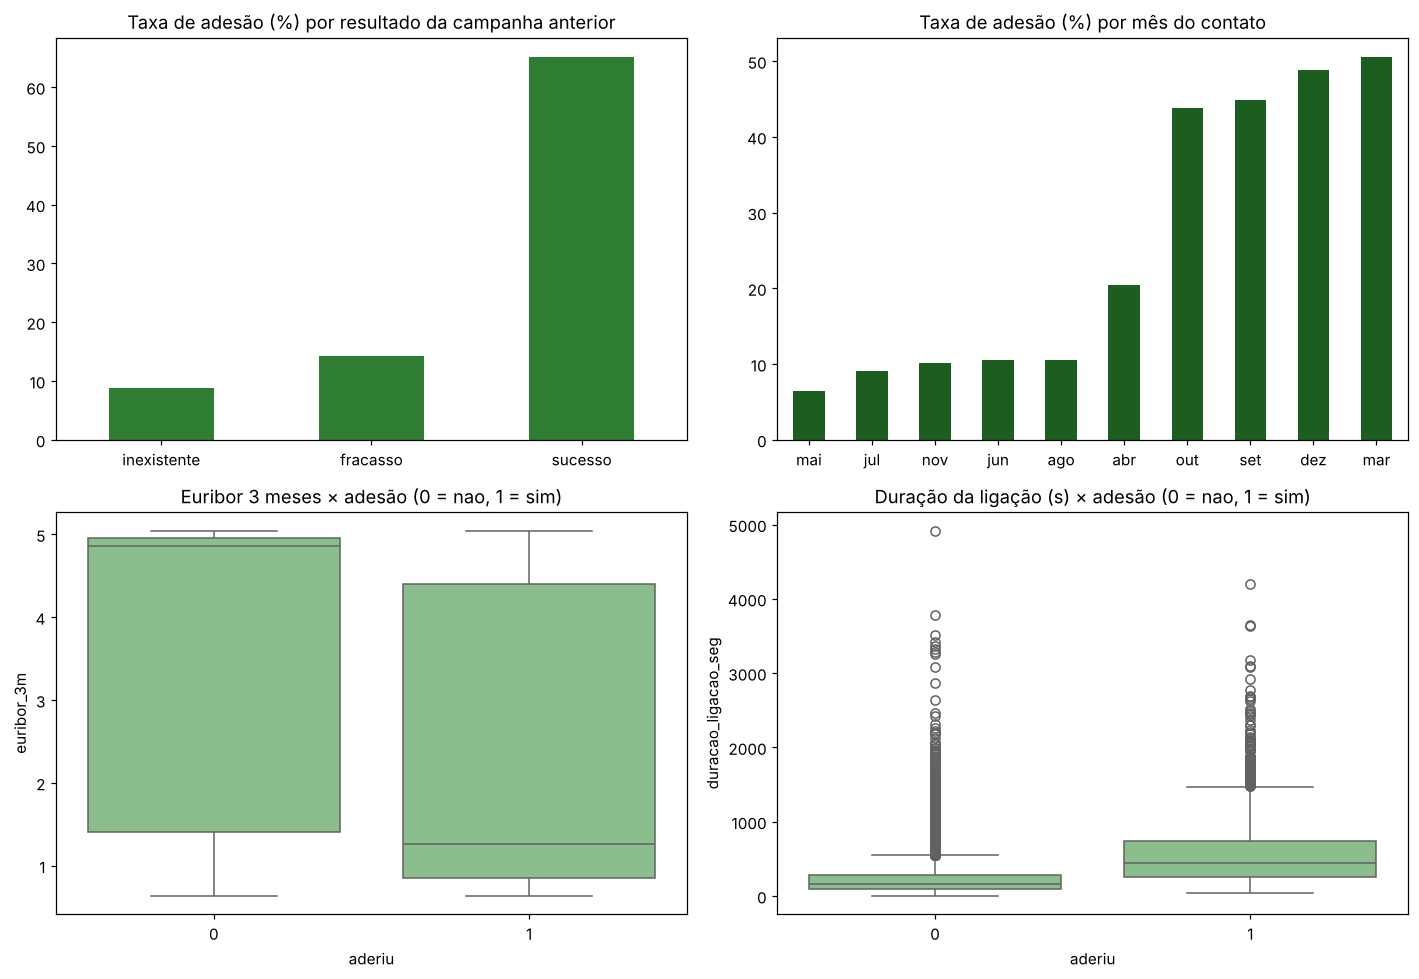

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
(df.groupby("resultado_campanha_anterior")["aderiu"].mean() * 100).sort_values().plot.bar(ax=ax[0, 0], color="#2E7D32")
ax[0, 0].set_title("Taxa de adesão (%) por resultado da campanha anterior")
(df.groupby("mes")["aderiu"].mean() * 100).sort_values().plot.bar(ax=ax[0, 1], color="#1B5E20")
ax[0, 1].set_title("Taxa de adesão (%) por mês do contato")
sns.boxplot(data=df, x="aderiu", y="euribor_3m", ax=ax[1, 0], color="#81C784")
ax[1, 0].set_title("Euribor 3 meses × adesão (0 = nao, 1 = sim)")
sns.boxplot(data=df, x="aderiu", y="duracao_ligacao_seg", ax=ax[1, 1], color="#81C784")
ax[1, 1].set_title("Duração da ligação (s) × adesão (0 = nao, 1 = sim)")
for a in ax[0]:
    a.tick_params(axis="x", rotation=0); a.set_xlabel("")
plt.tight_layout()
plt.show()

**Achados que exigem tratamento ou afetam a avaliação**
- **Desbalanceamento:** só ~11,3% aderiram. A acurácia engana (88,7% chutando “nao”); usar `stratify` e métricas da classe positiva.
- **12 duplicatas** → remover.
- **Sem NaN**, mas há `desconhecido` em 6 colunas (em `inadimplente`, 21%). Será mantido como categoria: o ausente pode ter significado.
- **`dias_desde_ultimo_contato = 999`** é um código (96% dos casos), não um número: usado como valor, distorceria a escala.
- **`inadimplente = sim`** tem só 3 casos: quase não informa nada.
- **Escalas muito diferentes** (ex.: `numero_empregados` ≈ 5.000 × `contatos_anteriores` 0–7) → padronizar (essencial para k-NN).
- **Duração da ligação** separa fortemente as classes, mas só existe depois da ligação (vazamento, ver Seção 2.3). Os indicadores macroeconômicos e o mês também separam bem, mas descrevem o *momento* do contato, não o cliente.

## 2. Preparação dos dados
### 2.1 Correções de coleta e recodificação (regras fixas, sem aprender nada dos dados → podem ser feitas antes da divisão)

In [ ]:
df = df.drop_duplicates()                                    # 41.188 -> 41.176 linhas
df["contatado_antes"] = (df["dias_desde_ultimo_contato"] != 999).astype(int)  # código 999 vira indicador 0/1
df = df.drop(columns="dias_desde_ultimo_contato")
print(df.shape)

(41176, 21)


### 2.2 Grupos de atributos e cenários
- **Cenário principal:** exclui `duracao_ligacao_seg` (só é conhecida ao fim da ligação, e duração 0 implica `nao`) e `contatos_campanha_atual` (contagem acumulada durante a campanha, que inclui o próprio último contato; antes de ligar, não se sabe quantas ligações haverá).
- **Cenário completo:** todos os atributos.

In [ ]:
numericas_todas = ["idade", "duracao_ligacao_seg", "contatos_campanha_atual", "contatos_anteriores", "contatado_antes",
                   "taxa_variacao_emprego", "indice_precos_consumidor", "indice_confianca_consumidor",
                   "euribor_3m", "numero_empregados"]
excluidas = ["duracao_ligacao_seg", "contatos_campanha_atual"]

cenarios = {
    "Principal": [c for c in numericas_todas if c not in excluidas],
    "Completo": numericas_todas,
}
X = df.drop(columns="aderiu")
y = df["aderiu"]

### 2.3 Divisão treino/teste (70/30, estratificada) — antes de qualquer transformação que aprenda dos dados

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
print(f"Treino: {len(X_treino)} | % adesão {y_treino.mean():.1%}")
print(f"Teste:  {len(X_teste)} | % adesão {y_teste.mean():.1%}")

Treino: 28823 | % adesão 11.3%
Teste:  12353 | % adesão 11.3%


### 2.4 Pré-processamento dentro do `Pipeline` (sem vazamento)
- Numéricas → `StandardScaler` (média e desvio aprendidos só no treino, e em cada dobra da validação cruzada).
- Categóricas → `OneHotEncoder(handle_unknown="ignore")`. Nenhuma tem ordem utilizável (`escolaridade` tem `desconhecido`, sem posição na escala).
- `sparse_output=False` devolve a tabela em formato comum (denso): o `GaussianNB` não aceita o formato compactado (esparso) que o One-Hot gera com muitas categorias.
- O mesmo pré-processamento vale para os três modelos.

In [ ]:
def preprocessamento(numericas):
    return ColumnTransformer([
        ("num", StandardScaler(), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
    ])

def montar(numericas, modelo):
    return Pipeline([("prep", preprocessamento(numericas)), ("modelo", modelo)])

print("Colunas após o pré-processamento (principal):",
      len(preprocessamento(cenarios["Principal"]).fit(X_treino).get_feature_names_out()))

Colunas após o pré-processamento (principal): 61


## 3. Modelagem
**Métrica de escolha: F1 da classe `sim`** (justificativa na Seção 4). Validação cruzada estratificada de 5 dobras, **só no treino**.
- **k-NN:** busca de `k` e `weights` numa **amostra estratificada de 35% do treino (≈ 10 mil linhas)** (o custo de previsão do k-NN cresce com n × d). O modelo final é treinado no treino completo.
- **Regressão logística:** busca de `C` e `class_weight` no treino completo (treino rápido). `class_weight="balanced"` compensa o desbalanceamento sem criar nem descartar dados.
- **Naive Bayes:** sem hiperparâmetros. Comparam-se `GaussianNB` e `BernoulliNB`.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_amostra, _, y_amostra, _ = train_test_split(X_treino, y_treino, test_size=0.65,
                                              stratify=y_treino, random_state=SEED)
print(f"Amostra para busca do k-NN: {len(X_amostra)} linhas | % adesão {y_amostra.mean():.1%}")

Amostra para busca do k-NN: 10088 linhas | % adesão 11.3%


In [ ]:
grade_knn = {"modelo__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 51], "modelo__weights": ["uniform", "distance"]}
grade_lr = {"modelo__C": [0.001, 0.01, 0.1, 1, 10, 100], "modelo__class_weight": [None, "balanced"]}

melhores = {}
for cen, num in cenarios.items():
    cols = num + categoricas
    busca_knn = GridSearchCV(montar(num, KNeighborsClassifier()), grade_knn, cv=cv,
                             scoring="f1", n_jobs=-1).fit(X_amostra[cols], y_amostra)
    busca_lr = GridSearchCV(montar(num, LogisticRegression(max_iter=1000)), grade_lr, cv=cv,
                            scoring="f1", n_jobs=-1).fit(X_treino[cols], y_treino)
    nb = {}
    for nome, m in [("GaussianNB", GaussianNB()), ("BernoulliNB", BernoulliNB())]:
        nb[nome] = cross_val_score(montar(num, m), X_treino[cols], y_treino, cv=cv, scoring="f1")
    melhores[cen] = {"knn": busca_knn.best_params_, "lr": busca_lr.best_params_}

    print(f"===== Cenário {cen} =====")
    print("k-NN  melhor:", busca_knn.best_params_, "| F1 CV =", round(busca_knn.best_score_, 3))
    print("RegLog melhor:", busca_lr.best_params_, "| F1 CV =", round(busca_lr.best_score_, 3))
    for nome, s in nb.items():
        print(f"{nome}: F1 CV = {s.mean():.3f} ± {s.std():.3f}")

===== Cenário Principal =====
k-NN  melhor: {'modelo__n_neighbors': 7, 'modelo__weights': 'uniform'} | F1 CV = 0.371
RegLog melhor: {'modelo__C': 10, 'modelo__class_weight': 'balanced'} | F1 CV = 0.446
GaussianNB: F1 CV = 0.407 ± 0.013
BernoulliNB: F1 CV = 0.400 ± 0.015
===== Cenário Completo =====
k-NN  melhor: {'modelo__n_neighbors': 9, 'modelo__weights': 'uniform'} | F1 CV = 0.471
RegLog melhor: {'modelo__C': 100, 'modelo__class_weight': 'balanced'} | F1 CV = 0.587
GaussianNB: F1 CV = 0.443 ± 0.011
BernoulliNB: F1 CV = 0.440 ± 0.013


Curvas da busca no cenário principal (laço de `cross_val_score`, como na escolha do k do material de k-NN): F1 médio na validação por `k` e por `C`.

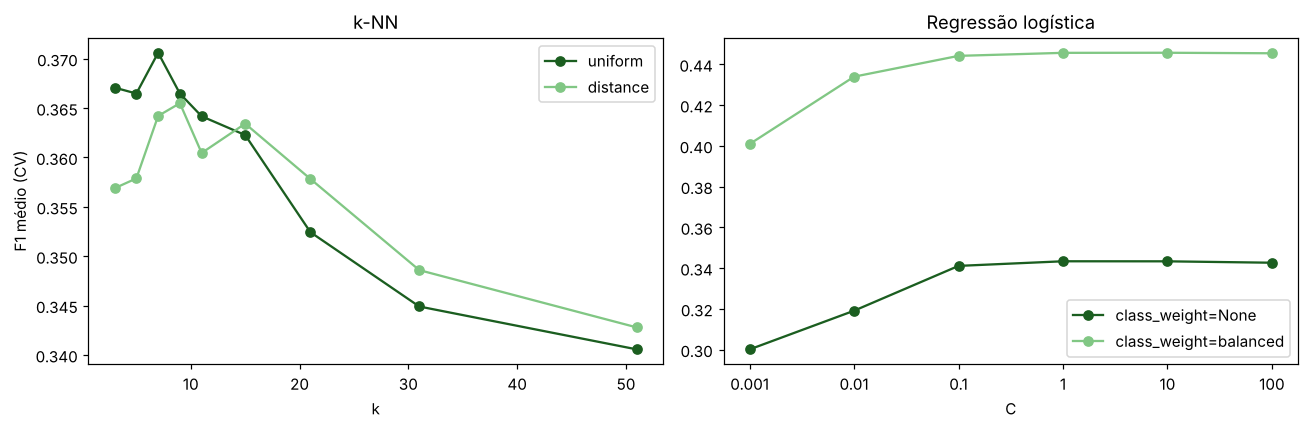

In [ ]:
num = cenarios["Principal"]; cols = num + categoricas
valores_k = [3, 5, 7, 9, 11, 15, 21, 31, 51]
valores_C = [0.001, 0.01, 0.1, 1, 10, 100]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for w, cor in [("uniform", "#1B5E20"), ("distance", "#81C784")]:
    notas = [cross_val_score(montar(num, KNeighborsClassifier(n_neighbors=k, weights=w)),
                             X_amostra[cols], y_amostra, cv=cv, scoring="f1").mean() for k in valores_k]
    ax[0].plot(valores_k, notas, marker="o", label=w, color=cor)
ax[0].set_xlabel("k"); ax[0].set_ylabel("F1 médio (CV)"); ax[0].set_title("k-NN"); ax[0].legend()
for cw, cor in [(None, "#1B5E20"), ("balanced", "#81C784")]:
    notas = [cross_val_score(montar(num, LogisticRegression(max_iter=1000, C=c, class_weight=cw)),
                             X_treino[cols], y_treino, cv=cv, scoring="f1").mean() for c in valores_C]
    ax[1].plot([str(c) for c in valores_C], notas, marker="o", label=f"class_weight={cw}", color=cor)
ax[1].set_xlabel("C"); ax[1].set_title("Regressão logística"); ax[1].legend()
plt.tight_layout(); plt.show()

**Variante de Naive Bayes:** após o One-Hot, a maioria das colunas é binária (favoreceria o `BernoulliNB`), mas os atributos mais informativos (indicadores macroeconômicos, idade) são contínuos, e o `BernoulliNB` os reduziria a “acima/abaixo da média”. O `GaussianNB` teve F1 ligeiramente maior na validação (diferença dentro do desvio) e foi o escolhido. As duas variantes aparecem na tabela final.

### 3.1 Modelos finais (treinados no treino completo de cada cenário)

In [ ]:
def modelos_finais(cen):
    num = cenarios[cen]
    k = melhores[cen]["knn"]; lr = melhores[cen]["lr"]
    return {
        "Linha de base (maioria)": montar(num, DummyClassifier(strategy="most_frequent")),
        "k-NN": montar(num, KNeighborsClassifier(n_neighbors=k["modelo__n_neighbors"],
                                                 weights=k["modelo__weights"])),
        "Naive Bayes (Gaussian)": montar(num, GaussianNB()),
        "Naive Bayes (Bernoulli)": montar(num, BernoulliNB()),
        "Regressão logística": montar(num, LogisticRegression(max_iter=1000, C=lr["modelo__C"],
                                                              class_weight=lr["modelo__class_weight"])),
    }

ajustados, prev, prob = {}, {}, {}
for cen, num in cenarios.items():
    cols = num + categoricas
    for nome, m in modelos_finais(cen).items():
        m.fit(X_treino[cols], y_treino)
        ajustados[(cen, nome)] = m
        prev[(cen, nome)] = m.predict(X_teste[cols])
        prob[(cen, nome)] = m.predict_proba(X_teste[cols])[:, 1]
for cen in cenarios:
    print(cen, melhores[cen])

Principal {'knn': {'modelo__n_neighbors': 7, 'modelo__weights': 'uniform'}, 'lr': {'modelo__C': 10, 'modelo__class_weight': 'balanced'}}
Completo {'knn': {'modelo__n_neighbors': 9, 'modelo__weights': 'uniform'}, 'lr': {'modelo__C': 100, 'modelo__class_weight': 'balanced'}}


## 4. Avaliação
**Métrica principal: F1 da classe `sim`.**
- Com 11,3% de positivos, a acurácia não serve: o modelo que nunca liga já tem 88,7%.
- Só o recall seria maximizado ligando para todos; só a precisão, ligando para quase ninguém.
- O banco quer encontrar quem adere (recall) sem desperdiçar ligações (precisão). O F1 só fica alto se os dois forem altos.

### 4.1 Métricas no conjunto de teste (por classe)

In [ ]:
for (cen, nome), p in prev.items():
    if nome == "Linha de base (maioria)":
        continue
    print(f"===== {cen} | {nome} =====")
    print(classification_report(y_teste, p, target_names=["nao (0)", "sim (1)"], digits=3, zero_division=0))

===== Principal | k-NN =====
              precision    recall  f1-score   support

     nao (0)      0.913     0.973     0.942     10961
     sim (1)      0.559     0.273     0.367      1392

    accuracy                          0.894     12353
   macro avg      0.736     0.623     0.654     12353
weighted avg      0.873     0.894     0.877     12353

===== Principal | Naive Bayes (Gaussian) =====
              precision    recall  f1-score   support

     nao (0)      0.944     0.838     0.888     10961
     sim (1)      0.324     0.611     0.423      1392

    accuracy                          0.812     12353
   macro avg      0.634     0.725     0.656     12353
weighted avg      0.874     0.812     0.836     12353

===== Principal | Naive Bayes (Bernoulli) =====
              precision    recall  f1-score   support

     nao (0)      0.946     0.826     0.882     10961
     sim (1)      0.313     0.627     0.418      1392

    accuracy                          0.803     12353
   m

### 4.2 Matrizes de confusão (linhas = real, colunas = previsto)

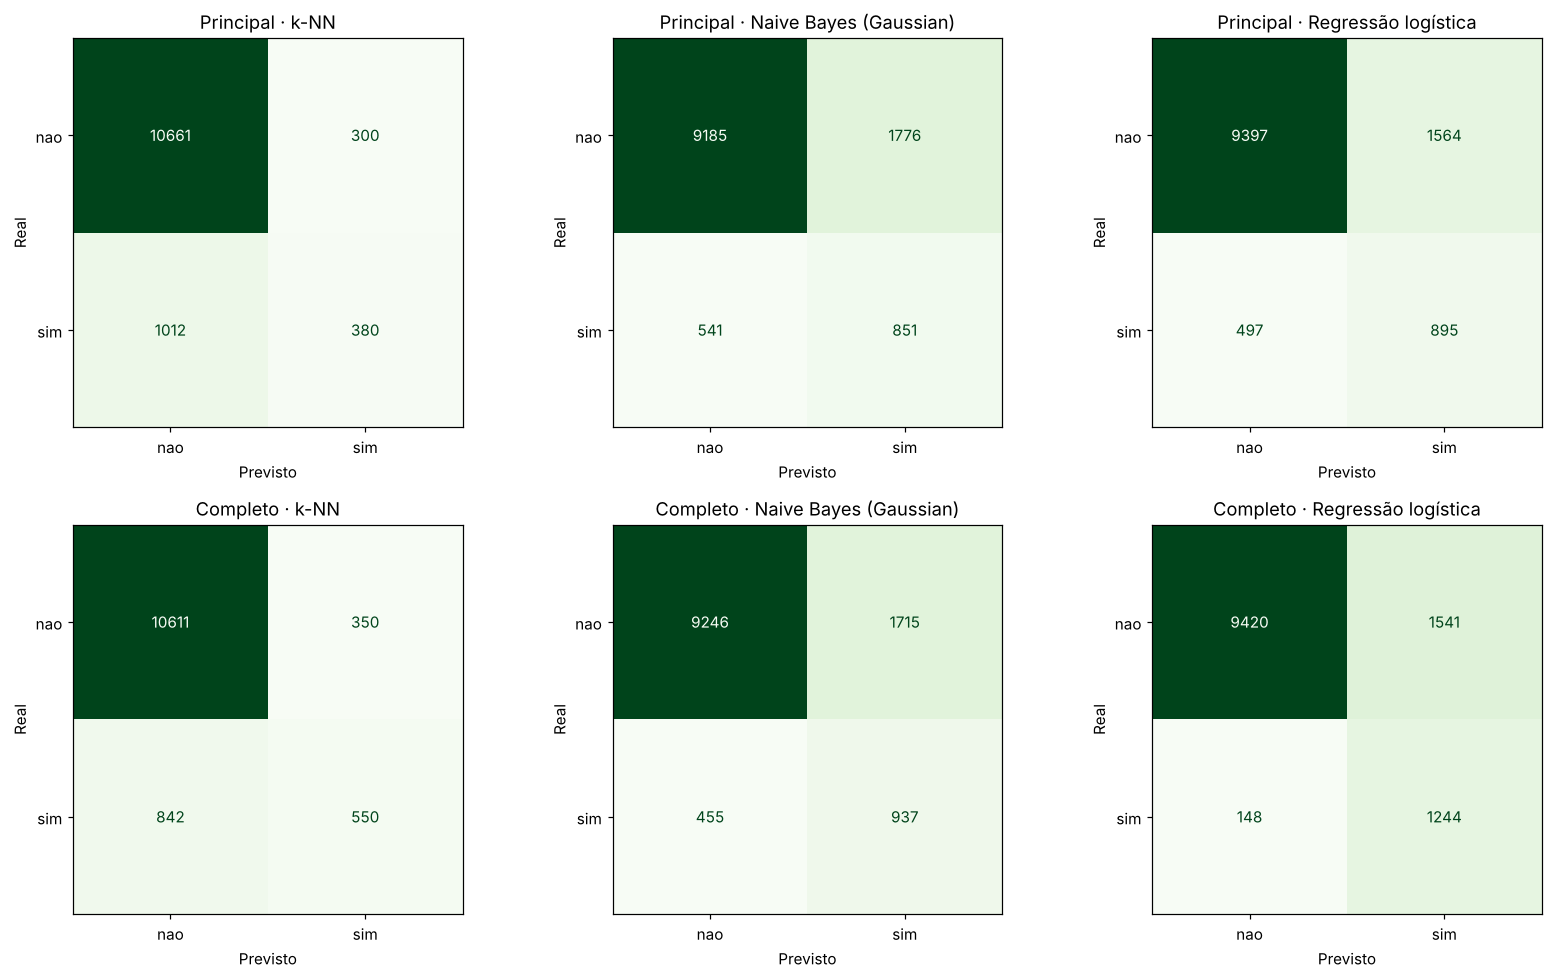

In [ ]:
principais = ["k-NN", "Naive Bayes (Gaussian)", "Regressão logística"]
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
for linha, cen in zip(ax, cenarios):
    for eixo, nome in zip(linha, principais):
        cm = confusion_matrix(y_teste, prev[(cen, nome)], labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=["nao", "sim"]).plot(ax=eixo, cmap="Greens", colorbar=False)
        eixo.set_title(f"{cen} · {nome}")
        eixo.set_xlabel("Previsto"); eixo.set_ylabel("Real")
plt.tight_layout(); plt.show()

### 4.3 Validação cruzada (5 dobras estratificadas, treino) e tabela consolidada

In [ ]:
linhas = []
for (cen, nome), m in ajustados.items():
    cols = cenarios[cen] + categoricas
    f1_cv = cross_val_score(m, X_treino[cols], y_treino, cv=cv, scoring="f1")
    p = prev[(cen, nome)]
    linhas.append({
        "Cenário": cen, "Modelo": nome,
        "Acurácia": accuracy_score(y_teste, p),
        "Precisão (0)": precision_score(y_teste, p, pos_label=0, zero_division=0),
        "Recall (0)": recall_score(y_teste, p, pos_label=0),
        "F1 (0)": f1_score(y_teste, p, pos_label=0),
        "Precisão (1)": precision_score(y_teste, p, zero_division=0),
        "Recall (1)": recall_score(y_teste, p),
        "F1 (1) teste": f1_score(y_teste, p),
        "F1 (1) CV média": f1_cv.mean(),
        "F1 (1) CV desvio": f1_cv.std(),
        "AUC teste": roc_auc_score(y_teste, prob[(cen, nome)]),
    })
tabela = pd.DataFrame(linhas).round(3)
tabela

,Cenário,Modelo,Acurácia,Precisão (0),Recall (0),F1 (0),Precisão (1),Recall (1),F1 (1) teste,F1 (1) CV média,F1 (1) CV desvio,AUC teste
0,Principal,Linha de base (maioria),0.887,0.887,1.000,0.940,0.000,0.000,0.000,0.000,0.000,0.500
1,Principal,k-NN,0.894,0.913,0.973,0.942,0.559,0.273,0.367,0.368,0.020,0.743
2,Principal,Naive Bayes (Gaussian),0.812,0.944,0.838,0.888,0.324,0.611,0.423,0.407,0.013,0.778
3,Principal,Naive Bayes (Bernoulli),0.803,0.946,0.826,0.882,0.313,0.627,0.418,0.400,0.015,0.778
4,Principal,Regressão logística,0.833,0.950,0.857,0.901,0.364,0.643,0.465,0.446,0.014,0.803
5,Completo,Linha de base (maioria),0.887,0.887,1.000,0.940,0.000,0.000,0.000,0.000,0.000,0.500
6,Completo,k-NN,0.904,0.926,0.968,0.947,0.611,0.395,0.480,0.487,0.011,0.897
7,Completo,Naive Bayes (Gaussian),0.824,0.953,0.844,0.895,0.353,0.673,0.463,0.443,0.011,0.839
8,Completo,Naive Bayes (Bernoulli),0.822,0.949,0.844,0.894,0.344,0.644,0.449,0.440,0.013,0.820
9,Completo,Regressão logística,0.863,0.985,0.859,0.918,0.447,0.894,0.596,0.587,0.007,0.938


### 4.4 Custo dos erros e limiar (regressão logística, cenário principal)
- **FN:** cliente que aderiria e não é contatado → venda (captação) perdida.
- **FP:** ligação sem adesão → custa só o tempo do operador.

O FN custa mais. Baixar o limiar aumenta o recall às custas da precisão.

In [ ]:
p_lr = prob[("Principal", "Regressão logística")]
linhas = []
for limiar in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pv = (p_lr >= limiar).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_teste, pv, labels=[0, 1]).ravel()
    linhas.append({"Limiar": limiar, "VP": vp, "FN": fn, "FP": fp, "VN": vn, "Ligações (VP+FP)": vp + fp,
                   "Precisão": vp / (vp + fp), "Recall": vp / (vp + fn), "F1": f1_score(y_teste, pv)})
pd.DataFrame(linhas).round(3)

,Limiar,VP,FN,FP,VN,Ligações (VP+FP),Precisão,Recall,F1
0,0.3,1212,180,6040,4921,7252,0.167,0.871,0.280
1,0.4,1015,377,2769,8192,3784,0.268,0.729,0.392
2,0.5,895,497,1564,9397,2459,0.364,0.643,0.465
3,0.6,855,537,1230,9731,2085,0.410,0.614,0.492
4,0.7,706,686,804,10157,1510,0.468,0.507,0.487


### 4.5 Coeficientes da regressão logística (cenário principal)
Atributos padronizados → efeito por **1 desvio-padrão**. Para categorias, efeito de pertencer à categoria. `e^β` > 1 aumenta a chance de adesão; < 1 diminui.

In [ ]:
rl = ajustados[("Principal", "Regressão logística")]
coef = pd.Series(rl.named_steps["modelo"].coef_[0], index=rl.named_steps["prep"].get_feature_names_out())
magnitude = np.sqrt(coef ** 2)                  # |β|
top5 = magnitude.nlargest(5).index              # 5 coeficientes de maior magnitude
pd.DataFrame({"β": coef[top5], "e^β (razão de chances)": np.exp(coef[top5])}).round(3)

,β,e^β (razão de chances)
num__taxa_variacao_emprego,-2.320,0.098
cat__mes_mar,1.291,3.636
num__indice_precos_consumidor,1.051,2.861
cat__mes_jun,-0.780,0.458
num__euribor_3m,0.756,2.129


In [ ]:
print("Correlação entre indicadores macroeconômicos (treino):")
X_treino[["taxa_variacao_emprego", "euribor_3m", "numero_empregados", "indice_precos_consumidor"]].corr().round(2)

Correlação entre indicadores macroeconômicos (treino):


,taxa_variacao_emprego,euribor_3m,numero_empregados,indice_precos_consumidor
taxa_variacao_emprego,1.00,0.97,0.91,0.77
euribor_3m,0.97,1.00,0.94,0.68
numero_empregados,0.91,0.94,1.00,0.52
indice_precos_consumidor,0.77,0.68,0.52,1.00


## 5. Conclusões
- **Modelo escolhido: regressão logística (cenário principal).** Tem o maior F1 da classe `sim` no teste e na validação cruzada, e o maior AUC. Também é interpretável.
- **O cenário completo tem números melhores por vazamento:** `duracao_ligacao_seg` só existe depois da ligação. Esse desempenho não se repetiria no uso real (decidir *antes* de ligar).
- **k-NN:** maior acurácia, mas recall baixo (deixa passar a maioria dos que aderem). **Naive Bayes:** recall razoável, mas precisão menor.
- Os coeficientes mais fortes são de **contexto** (indicadores macroeconômicos e mês), não do cliente. Esses indicadores são muito correlacionados entre si, o que torna os sinais dos pesos instáveis.